# July 1 Microlensing Paper-Analogue Notebook

Inline-only reproductions of the Gaia DR3 microlensing-paper plots that are currently possible for the July 1 review DB microlensing candidate set. The notebook intentionally writes no PNG/PDF/CSV/JSON artifacts; it displays figures and tables inline only.

The fit-dependent sections always refit the current 21-candidate microlensing cohort through `scripts.microlensing.fit_microlensing_candidates`.


## Setup and paths


In [1]:
from __future__ import annotations

import json
import os
import sqlite3
import sys
import warnings
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/malca-mplconfig")

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from IPython.display import Image as DisplayImage


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "malca").is_dir():
            return candidate
    for candidate in [start, *start.parents]:
        if (candidate / ".git").exists() and (candidate / "malca").is_dir():
            return candidate
    raise RuntimeError(f"Could not find repo root from {start}")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from malca.config import GAIA_TCB_EPOCH_JD, JD_OFFSET, KEPLER_BKJD_OFFSET, MJD_TO_JD, SKYPATROL_JD_OFFSET, TESS_BTJD_OFFSET
from malca.ltv.cmd import dustmaps_cmd_from_fields
from malca.plotting.lightcurve_publication import (
    FIG_SINGLE_COL_LC_WIDE,
    FIG_SINGLE_COL_MEDIUM,
    FIG_SINGLE_COL_SQUARE,
    FIG_TWO_COL_WIDTH,
    apply_publication_rcparams,
    filter_lightcurve,
    load_lightcurve,
    plot_lightcurve_panel,
)
from malca.review.lightcurve_sources import EXTERNAL_LC_SPECS, EXTERNAL_SOURCE_LABELS, load_external_lc_frame
from scripts.microlensing import fit_microlensing_candidates, plot_candidate_fit

apply_publication_rcparams(plt)
warnings.filterwarnings("once", category=RuntimeWarning)

RUN_ROOT = REPO_ROOT / "output" / "runs" / "dat3-full-extended_2026-07-01-v4"
DB_PATH = RUN_ROOT / "review" / "review.db"
RESULTS_DIR = RUN_ROOT / "results"
LIGHTCURVE_DIR = RUN_ROOT / "bundle_assets" / "lightcurves"
EXTERNAL_MANIFEST_PATH = RESULTS_DIR / "external_lc_manifest.parquet"
GAIA_BACKGROUND_PATHS = [
    REPO_ROOT / "input" / "gaia" / "gaia_dr3_crossmatched.parquet",
    REPO_ROOT / "output" / "cache" / "catalogs" / "gaia" / "gaia_dr3_crossmatched.parquet",
]

FIT_WORKERS = 1
PLOT_DUST_BACKGROUND = True
EXPORT_PAPER_FIGURES = True
EXTERNAL_SOURCES = ["neowise", "ps1", "ztf", "gaia_epoch", "crts"]

assert DB_PATH.exists(), DB_PATH
assert LIGHTCURVE_DIR.exists(), LIGHTCURVE_DIR

FIGURE_SUMMARY: list[dict[str, object]] = []
SUMMARY: dict[str, object] = {
    "run_root": str(RUN_ROOT.relative_to(REPO_ROOT)),
    "review_db": str(DB_PATH.relative_to(REPO_ROOT)),
    "external_manifest": str(EXTERNAL_MANIFEST_PATH.relative_to(REPO_ROOT)),
    "fit_workers": FIT_WORKERS,
    "exploratory_inline_only": True,
    "publication_figures": "inline_notebook_outputs",
    "publication_export_enabled": EXPORT_PAPER_FIGURES,
    "publication_export_dir": str((RESULTS_DIR / "microlensing_paper_analogues").relative_to(REPO_ROOT)),
}

print(f"repo root: {REPO_ROOT}")
print(f"run root : {RUN_ROOT}")
print(f"review DB: {DB_PATH}")
print("Exploratory and publication figures render inline in the notebook.")
if EXPORT_PAPER_FIGURES:
    print("Publication PDF/PNG export is enabled.")


Matplotlib is building the font cache; this may take a moment.
/opt/homebrew/Caskroom/miniconda/base/envs/malca/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Please note the archive will not be accessible on 21 July at 14:30 CEST for some minutes, due to maintenance works. Apologies for the inconveniences.
repo root: /Users/calder/code/malca
run root : /Users/calder/code/malca/output/runs/dat3-full-extended_2026-07-01-v4
review DB: /Users/calder/code/malca/output/runs/dat3-full-extended_2026-07-01-v4/review/review.db
Exploratory and publication figures render inline in the notebook.
Publication PDF/PNG export is enabled.


/opt/homebrew/Caskroom/miniconda/base/envs/malca/lib/python3.10/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


## Shared helpers


In [2]:
def record_figure(
    figure: str,
    status: str,
    data_source: str,
    caveat: str,
    n_rows: int | None = None,
) -> None:
    FIGURE_SUMMARY.append(
        {
            "figure": figure,
            "status": status,
            "data_source": data_source,
            "caveat": caveat,
            "n_rows": n_rows,
        }
    )


def show_inline(fig, figure: str, *, status: str, data_source: str, caveat: str, n_rows: int | None = None) -> None:
    record_figure(figure, status, data_source, caveat, n_rows)
    fig.tight_layout()
    plt.show()


def numeric(frame: pd.DataFrame, col: str) -> pd.Series:
    if col not in frame.columns:
        return pd.Series(np.nan, index=frame.index, dtype="float64")
    return pd.to_numeric(frame[col], errors="coerce")


def finite_count(frame: pd.DataFrame, col: str) -> int:
    return int(np.isfinite(numeric(frame, col)).sum())


def candidate_numeric_id(candidate_id: object) -> str:
    text = str(candidate_id or "").strip()
    return text[4:] if text.startswith("stv_") else text


def resolve_local_lc_path(candidate_id: object, stored_path: object = None) -> Path | None:
    stored_text = str(stored_path or "").strip()
    if stored_text:
        stored = Path(stored_text)
        if stored.exists():
            return stored
    stem = candidate_numeric_id(candidate_id)
    for suffix in (".dat3", ".raw2", ".dat2", ".dat", ".csv"):
        path = LIGHTCURVE_DIR / f"{stem}{suffix}"
        if path.exists():
            return path
    matches = sorted(LIGHTCURVE_DIR.glob(f"{stem}.*"))
    return matches[0] if matches else None


def wrap_l_180(l_deg: pd.Series | np.ndarray) -> np.ndarray:
    l = pd.to_numeric(pd.Series(l_deg), errors="coerce").to_numpy(dtype=float)
    return ((l + 180.0) % 360.0) - 180.0


def lb_to_mollweide(l_deg: pd.Series | np.ndarray, b_deg: pd.Series | np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    return -np.radians(wrap_l_180(l_deg)), np.radians(pd.to_numeric(pd.Series(b_deg), errors="coerce").to_numpy(dtype=float))


def as_full_jd(values: pd.Series | np.ndarray) -> pd.Series:
    out = pd.to_numeric(pd.Series(values), errors="coerce")
    finite = np.isfinite(out)
    high = finite & (out > 3_000_000.0)
    while bool(high.any()):
        out.loc[high] = out.loc[high] - SKYPATROL_JD_OFFSET
        finite = np.isfinite(out)
        high = finite & (out > 3_000_000.0)
    reduced = finite & (out < 50_000.0)
    out.loc[reduced] = out.loc[reduced] + SKYPATROL_JD_OFFSET
    return out


def jd_minus_2450000(values: pd.Series | np.ndarray) -> pd.Series:
    return as_full_jd(values) - SKYPATROL_JD_OFFSET


def jd_minus_display_offset(values: pd.Series | np.ndarray) -> pd.Series:
    return as_full_jd(values) - JD_OFFSET


def load_gaia_cmd_background(max_rows: int = 200_000) -> pd.DataFrame:
    for path in GAIA_BACKGROUND_PATHS:
        if not path.exists():
            continue
        try:
            bg = pd.read_parquet(path, columns=["bp_rp", "phot_g_mean_mag", "parallax"])
        except Exception:
            try:
                bg = pd.read_parquet(path)
            except Exception:
                continue
        needed = [col for col in ["bp_rp", "phot_g_mean_mag", "parallax"] if col in bg.columns]
        bg = bg[needed].copy()
        if len(bg) > max_rows:
            bg = bg.sample(max_rows, random_state=7)
        return bg
    return pd.DataFrame()


def plot_optional_dust_background(ax) -> bool:
    if not PLOT_DUST_BACKGROUND:
        return False
    try:
        from astropy.coordinates import SkyCoord
        import astropy.units as u
        from dustmaps.sfd import SFDQuery

        lon_grid = np.linspace(-np.pi, np.pi, 360)
        lat_grid = np.linspace(-np.pi / 2.0, np.pi / 2.0, 180)
        lon, lat = np.meshgrid(lon_grid, lat_grid)
        coords = SkyCoord(l=-lon * u.rad, b=lat * u.rad, frame="galactic")
        ebv = SFDQuery()(coords)
        ax.pcolormesh(lon, lat, np.log10(ebv + 0.1), cmap="Greys", alpha=0.45, shading="auto", zorder=0)
        return True
    except Exception as exc:
        print(f"Dust background skipped: {exc}")
        return False


def add_mollweide_grid(ax) -> None:
    ax.grid(True, alpha=0.35, linestyle="--", linewidth=0.6)
    ax.set_xlabel("Galactic longitude")
    ax.set_ylabel("Galactic latitude")


def compact_columns(frame: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    return frame[[col for col in columns if col in frame.columns]].copy()


## Cohort load and capability audit


In [3]:
MICROLENSING_WHERE = """
    lower(trim(coalesce(event_class, ''))) = 'microlensing'
    OR lower(trim(coalesce(morphology_secondary, ''))) = 'possible_microlensing_event'
    OR EXISTS (
        SELECT 1
        FROM json_each(
            CASE
                WHEN json_valid(morphology_secondary_json) THEN morphology_secondary_json
                ELSE '[]'
            END
        ) AS secondary
        WHERE lower(trim(cast(secondary.value AS TEXT))) = 'possible_microlensing_event'
    )
"""

review_cols = [
    "candidate_id",
    "event_class",
    "morphology_primary",
    "morphology_secondary",
    "morphology_secondary_json",
    "physical_primary",
    "physical_secondary",
    "workflow_status",
    "status",
    "notes",
]

with sqlite3.connect(DB_PATH) as conn:
    reviews = pd.read_sql_query(
        f"SELECT {', '.join(review_cols)} FROM reviews WHERE {MICROLENSING_WHERE} ORDER BY candidate_id",
        conn,
    )
    candidate_ids = reviews["candidate_id"].astype(str).tolist()
    placeholders = ",".join("?" for _ in candidate_ids)
    candidates = pd.read_sql_query(
        f"SELECT * FROM candidates WHERE candidate_id IN ({placeholders}) ORDER BY candidate_id",
        conn,
        params=candidate_ids,
    )

cohort = candidates.merge(reviews, on="candidate_id", how="left", suffixes=("", "_review"))
cohort["local_lc_path"] = [resolve_local_lc_path(row.candidate_id, getattr(row, "lc_path", None)) for row in cohort.itertuples(index=False)]
cohort["has_local_lightcurve"] = cohort["local_lc_path"].map(lambda p: bool(p is not None and Path(p).exists()))
cohort["l_wrapped_deg"] = wrap_l_180(cohort["gal_l"])
cohort["parallax_snr"] = numeric(cohort, "parallax") / numeric(cohort, "parallax_error")
cohort["gaia_astrometry_ok"] = (numeric(cohort, "ruwe") < 1.5) & (cohort["parallax_snr"] > 1.0)
cohort["paper_region"] = np.select(
    [cohort["l_wrapped_deg"].abs() < 5.0, cohort["l_wrapped_deg"].abs().between(5.0, 10.0, inclusive="left")],
    ["inner_bulge_like", "outer_bulge_like"],
    default="disk_field_like",
)

manifest = pd.DataFrame()
if EXTERNAL_MANIFEST_PATH.exists():
    manifest = pd.read_parquet(EXTERNAL_MANIFEST_PATH)
    manifest = manifest[manifest["candidate_id"].astype(str).isin(cohort["candidate_id"].astype(str))].copy()

external_counts = (
    manifest.groupby(["candidate_id", "source"]).size().unstack(fill_value=0)
    if not manifest.empty
    else pd.DataFrame(index=cohort["candidate_id"])
)
for source in EXTERNAL_SOURCES:
    if source not in external_counts.columns:
        external_counts[source] = 0
external_counts = external_counts[EXTERNAL_SOURCES].reset_index()
cohort = cohort.merge(external_counts, on="candidate_id", how="left", suffixes=("", "_external_count"))
for source in EXTERNAL_SOURCES:
    cohort[source] = pd.to_numeric(cohort[source], errors="coerce").fillna(0).astype(int)
cohort["n_external_sources"] = (cohort[EXTERNAL_SOURCES] > 0).sum(axis=1)

SUMMARY["n_microlensing_candidates"] = int(len(cohort))
SUMMARY["n_external_lc_rows"] = int(len(manifest))

n_event_class = int(reviews["event_class"].fillna("").str.strip().str.lower().eq("microlensing").sum())
print(f"Microlensing cohort rows: {len(cohort)} ({n_event_class} event-class; {len(cohort) - n_event_class} morphology-only)")
display(compact_columns(
    cohort,
    [
        "candidate_id", "event_class", "morphology_secondary", "morphology_secondary_json",
        "physical_primary", "physical_secondary", "workflow_status",
        "gal_l", "gal_b", "phot_g_mean_mag", "baseline_mag", "bp_rp", "parallax", "parallax_error", "ruwe",
        "mg", "mg0", "distance_gspphot", "jump_best_t0", "microlens_te_days", "has_local_lightcurve",
        *EXTERNAL_SOURCES,
    ],
))


Microlensing cohort rows: 22


,candidate_id,event_class,physical_primary,physical_secondary,workflow_status,gal_l,gal_b,phot_g_mean_mag,baseline_mag,bp_rp,...,mg0,distance_gspphot,jump_best_t0,microlens_te_days,has_local_lightcurve,neowise,ps1,ztf,gaia_epoch,crts
0,stv_103079263205,microlensing,microlensing,generic_microlensing_candidate,reviewed,134.192174,-0.083764,11.829720,12.493000,1.055785,...,NaN,NaN,9094.274390,None,True,1,1,1,1,0
1,stv_111669286812,microlensing,microlensing,generic_microlensing_candidate,needs_followup,127.898871,-0.611228,12.286943,12.833886,0.897701,...,-1.418551,2475.501465,10511.389269,None,True,0,1,1,0,0
2,stv_120259784233,microlensing,microlensing,generic_microlensing_candidate,reviewed,153.089123,-9.399656,12.474867,13.766090,1.760533,...,NaN,NaN,9910.482875,None,True,1,1,1,0,0
3,stv_171799355659,microlensing,microlensing,generic_microlensing_candidate,reviewed,55.556609,-6.302081,13.215246,13.861907,1.288610,...,1.090285,2193.030518,10174.273229,None,True,1,1,1,0,0
4,stv_188979054063,microlensing,microlensing,generic_microlensing_candidate,reviewed,187.003891,-0.125975,12.108075,12.642120,1.008166,...,NaN,NaN,8487.200582,None,True,1,1,1,0,1
5,stv_206158789308,microlensing,microlensing,generic_microlensing_candidate,reviewed,89.369669,-5.741512,13.492368,13.527102,0.349574,...,-0.754731,5125.287598,9390.211808,None,True,1,1,1,1,0
6,stv_257698235806,microlensing,microlensing,generic_microlensing_candidate,reviewed,266.514619,-2.707861,13.592773,13.895394,0.937874,...,2.999503,930.085327,9523.232147,None,True,1,0,0,1,0
7,stv_326418117943,microlensing,microlensing,generic_microlensing_candidate,reviewed,18.505060,-0.848241,12.407984,12.881874,0.866184,...,-1.246520,2369.354004,9506.262529,None,True,1,1,1,0,0
8,stv_34360800532,microlensing,microlensing,generic_microlensing_candidate,reviewed,88.925095,0.334465,12.725737,12.934900,0.747469,...,-2.943113,3987.111816,8902.562566,None,True,1,1,1,0,0
9,stv_489626721133,microlensing,microlensing,generic_microlensing_candidate,reviewed,230.175937,-3.226622,13.567831,14.008000,0.796513,...,-1.262906,4760.236328,7627.473615,None,True,1,1,1,0,0


In [4]:
coverage_specs = [
    ("Galactic coordinates", ["gal_l", "gal_b"]),
    ("Gaia/MALCA magnitudes and color", ["baseline_mag", "phot_g_mean_mag", "phot_bp_mean_mag", "phot_rp_mean_mag", "bp_rp"]),
    ("Parallax/RUWE", ["parallax", "parallax_error", "ruwe"]),
    ("Distance/CMD stored", ["distance_gspphot", "mg", "mg0"]),
    ("DB event-time proxy", ["jump_best_t0"]),
    ("Catalog microlens tE", ["microlens_te_days"]),
]
coverage_rows: list[dict[str, object]] = []
for group, cols in coverage_specs:
    for col in cols:
        n = finite_count(cohort, col)
        coverage_rows.append({"group": group, "field": col, "available": n, "total": len(cohort), "fraction": n / max(len(cohort), 1)})
coverage_rows.append({"group": "Local ASAS-SN light curve", "field": "local_lc_path", "available": int(cohort["has_local_lightcurve"].sum()), "total": len(cohort), "fraction": float(cohort["has_local_lightcurve"].mean())})
for source in EXTERNAL_SOURCES:
    n = int((cohort[source] > 0).sum())
    coverage_rows.append({"group": "External light curve", "field": source, "available": n, "total": len(cohort), "fraction": n / max(len(cohort), 1)})
coverage = pd.DataFrame(coverage_rows)
display(coverage)


,group,field,available,total,fraction
0,Galactic coordinates,gal_l,22,22,1.000000
1,Galactic coordinates,gal_b,22,22,1.000000
2,Gaia/MALCA magnitudes and color,baseline_mag,22,22,1.000000
3,Gaia/MALCA magnitudes and color,phot_g_mean_mag,22,22,1.000000
4,Gaia/MALCA magnitudes and color,phot_bp_mean_mag,22,22,1.000000
5,Gaia/MALCA magnitudes and color,phot_rp_mean_mag,22,22,1.000000
6,Gaia/MALCA magnitudes and color,bp_rp,22,22,1.000000
7,Parallax/RUWE,parallax,22,22,1.000000
8,Parallax/RUWE,parallax_error,22,22,1.000000
9,Parallax/RUWE,ruwe,22,22,1.000000


## DB-only analogues


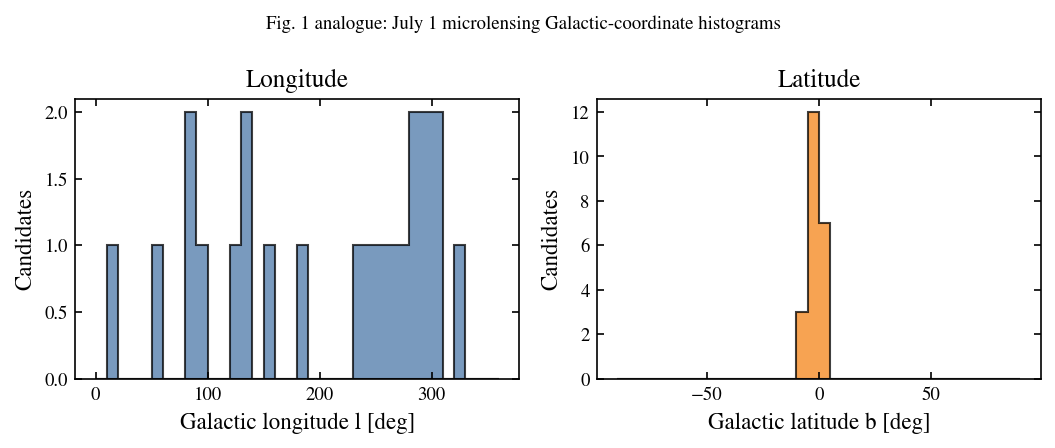

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.0))

l_vals = numeric(cohort, "gal_l").dropna()
b_vals = numeric(cohort, "gal_b").dropna()
axes[0].hist(l_vals, bins=np.linspace(0, 360, 37), histtype="stepfilled", color="#4C78A8", alpha=0.75, edgecolor="black")
axes[0].set_xlabel("Galactic longitude l [deg]")
axes[0].set_ylabel("Candidates")
axes[0].set_title("Longitude")

axes[1].hist(b_vals, bins=np.linspace(-90, 90, 37), histtype="stepfilled", color="#F58518", alpha=0.75, edgecolor="black")
axes[1].set_xlabel("Galactic latitude b [deg]")
axes[1].set_ylabel("Candidates")
axes[1].set_title("Latitude")

for ax in axes:
    ax.tick_params(direction="in", top=True, right=True)

fig.suptitle("Fig. 1 analogue: July 1 microlensing Galactic-coordinate histograms", fontsize=9)
show_inline(
    fig,
    "Fig. 1 analogue",
    status="ready_db_analog",
    data_source="review.db candidates.gal_l/gal_b",
    caveat="No Gaia Sample A/B/A+B split; current cohort only.",
    n_rows=len(cohort),
)


/opt/homebrew/Caskroom/miniconda/base/envs/malca/lib/python3.10/site-packages/dustmaps/config.py:74: ConfigWarning: Configuration file not found:

    /Users/calder/.dustmapsrc

To create a new configuration file in the default location, run the following python code:

    from dustmaps.config import config
    config.reset()

Note that this will delete your configuration! For example, if you have specified a data directory, then dustmaps will forget about its location.
  warn(('Configuration file not found:\n\n'


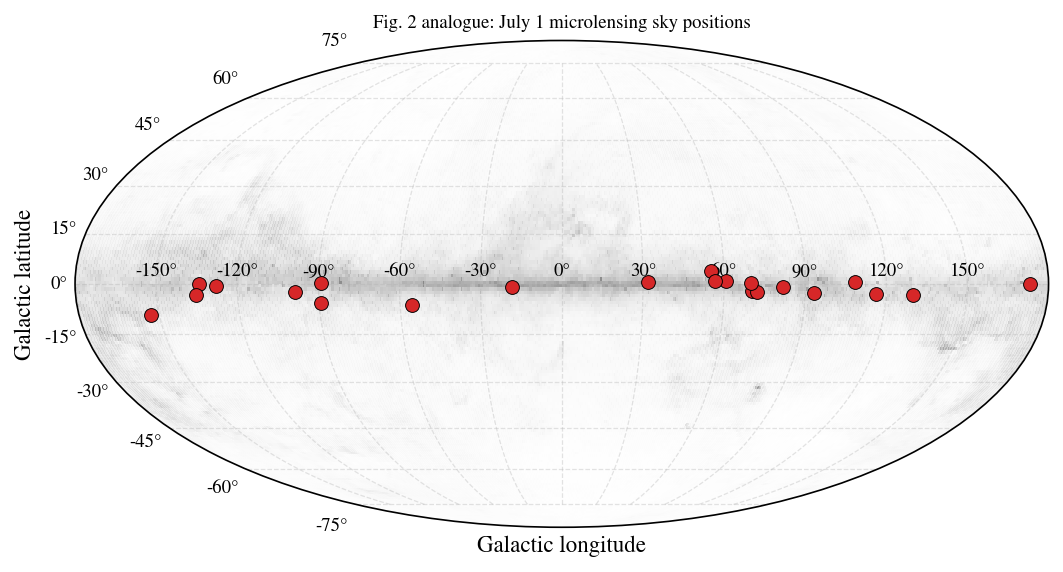

In [6]:
fig, ax = plt.subplots(figsize=(7.2, 3.8), subplot_kw={"projection": "mollweide"})
dust_ok = plot_optional_dust_background(ax)
x, y = lb_to_mollweide(cohort["gal_l"], cohort["gal_b"])
mask = np.isfinite(x) & np.isfinite(y)
ax.scatter(x[mask], y[mask], s=44, c="#D62728", edgecolors="black", linewidths=0.45, zorder=3)
add_mollweide_grid(ax)
ax.set_title("Fig. 2 analogue: July 1 microlensing sky positions", fontsize=9)
show_inline(
    fig,
    "Fig. 2 analogue",
    status="ready_db_analog",
    data_source="review.db coordinates" + (" + optional SFD dust background" if dust_ok else ""),
    caveat="Exact Gaia EDR3 all-sky background is not local; dust background is only contextual when available.",
    n_rows=int(mask.sum()),
)


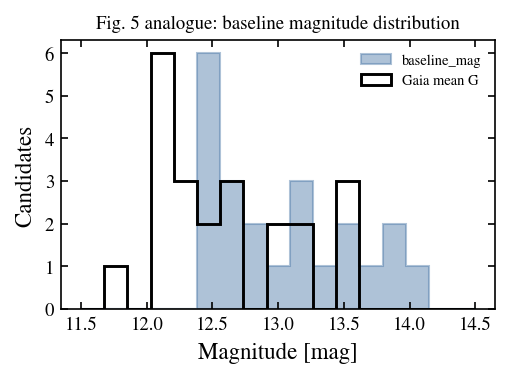

In [7]:
fig, ax = plt.subplots(figsize=FIG_SINGLE_COL_MEDIUM)
base = numeric(cohort, "baseline_mag").dropna()
gaia_g = numeric(cohort, "phot_g_mean_mag").dropna()
all_vals = pd.concat([base, gaia_g]).dropna()
if all_vals.empty:
    bins = np.linspace(10, 20, 20)
else:
    lo = np.floor(float(all_vals.min()) * 2.0) / 2.0
    hi = np.ceil(float(all_vals.max()) * 2.0) / 2.0
    bins = np.linspace(lo, hi, 18)
ax.hist(base, bins=bins, histtype="stepfilled", color="#4C78A8", alpha=0.45, edgecolor="#4C78A8", label="baseline_mag")
ax.hist(gaia_g, bins=bins, histtype="step", color="black", linewidth=1.4, label="Gaia mean G")
ax.set_xlabel("Magnitude [mag]")
ax.set_ylabel("Candidates")
ax.set_title("Fig. 5 analogue: baseline magnitude distribution", fontsize=9)
ax.legend(frameon=False, fontsize=7)
ax.tick_params(direction="in", top=True, right=True)
show_inline(
    fig,
    "Fig. 5 analogue",
    status="ready_db_analog",
    data_source="review.db baseline_mag and phot_g_mean_mag",
    caveat="Uses MALCA baseline/mean Gaia G, not Gaia paczynski0_g0.",
    n_rows=int(max(len(base), len(gaia_g))),
)


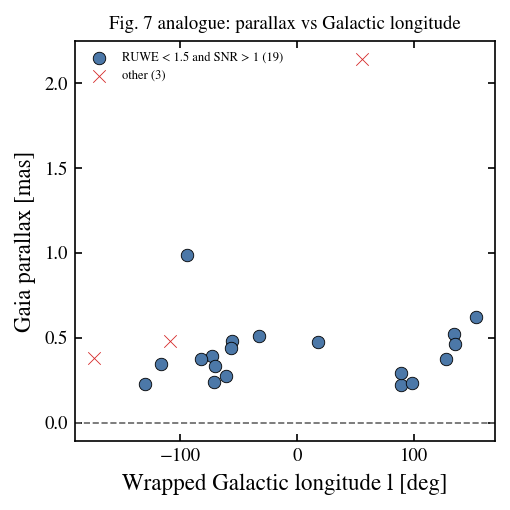

In [8]:
fig, ax = plt.subplots(figsize=FIG_SINGLE_COL_SQUARE)
plot_df = cohort.copy()
plot_df["parallax"] = numeric(plot_df, "parallax")
plot_df["parallax_error"] = numeric(plot_df, "parallax_error")
plot_df["ruwe"] = numeric(plot_df, "ruwe")
plot_df["l_wrapped_deg"] = wrap_l_180(plot_df["gal_l"])
plot_df["parallax_snr"] = plot_df["parallax"] / plot_df["parallax_error"]
plot_df["quality"] = np.where((plot_df["ruwe"] < 1.5) & (plot_df["parallax_snr"] > 1.0), "RUWE < 1.5 and SNR > 1", "other")
for label, marker, color in [("RUWE < 1.5 and SNR > 1", "o", "#4C78A8"), ("other", "x", "#D62728")]:
    part = plot_df[plot_df["quality"].eq(label)]
    ax.scatter(part["l_wrapped_deg"], part["parallax"], s=36, marker=marker, c=color, edgecolors="black" if marker == "o" else None, linewidths=0.4, label=f"{label} ({len(part)})")
ax.axhline(0.0, color="0.4", linewidth=0.8, linestyle="--")
ax.set_xlabel("Wrapped Galactic longitude l [deg]")
ax.set_ylabel("Gaia parallax [mas]")
ax.set_title("Fig. 7 analogue: parallax vs Galactic longitude", fontsize=9)
ax.legend(frameon=False, fontsize=6)
ax.tick_params(direction="in", top=True, right=True)
show_inline(
    fig,
    "Fig. 7 analogue",
    status="ready_db_analog",
    data_source="review.db parallax/parallax_error/ruwe/gal_l",
    caveat="Uses July 1 candidates only; marker split mirrors the paper quality idea.",
    n_rows=int(plot_df[["l_wrapped_deg", "parallax", "ruwe"]].dropna().shape[0]),
)


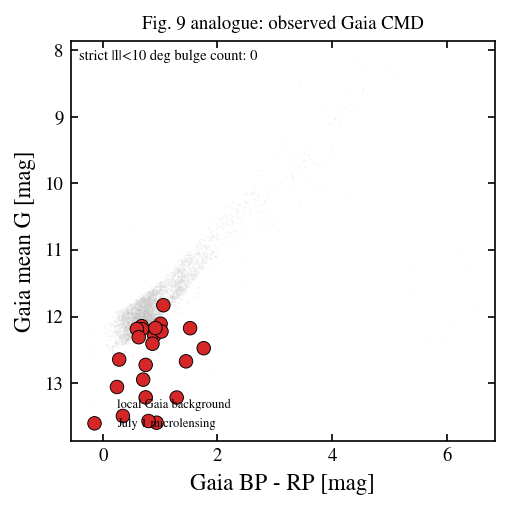

In [9]:
bg = load_gaia_cmd_background()
fig, ax = plt.subplots(figsize=FIG_SINGLE_COL_SQUARE)
if {"bp_rp", "phot_g_mean_mag"}.issubset(bg.columns):
    bgx = pd.to_numeric(bg["bp_rp"], errors="coerce")
    bgy = pd.to_numeric(bg["phot_g_mean_mag"], errors="coerce")
    ok_bg = np.isfinite(bgx) & np.isfinite(bgy)
    ax.scatter(bgx[ok_bg], bgy[ok_bg], s=1.0, c="0.75", alpha=0.12, edgecolors="none", rasterized=True, label="local Gaia background")

x = numeric(cohort, "bp_rp")
y = numeric(cohort, "phot_g_mean_mag")
region_color = np.where(cohort["paper_region"].eq("disk_field_like"), "#D62728", "#4C78A8")
ok = np.isfinite(x) & np.isfinite(y)
ax.scatter(x[ok], y[ok], s=42, c=region_color[ok], edgecolors="black", linewidths=0.45, label="July 1 microlensing")
ax.invert_yaxis()
ax.set_xlabel("Gaia BP - RP [mag]")
ax.set_ylabel("Gaia mean G [mag]")
ax.set_title("Fig. 9 analogue: observed Gaia CMD", fontsize=9)
ax.text(0.02, 0.98, f"strict |l|<10 deg bulge count: {int((cohort['l_wrapped_deg'].abs() < 10).sum())}", transform=ax.transAxes, ha="left", va="top", fontsize=7)
ax.legend(frameon=False, fontsize=6, loc="lower left")
ax.tick_params(direction="in", top=True, right=True)
show_inline(
    fig,
    "Fig. 9 analogue",
    status="ready_db_analog",
    data_source="review.db Gaia BP/RP/G; optional local Gaia background",
    caveat="Observed CMD only; the current set has no strict Gaia-paper bulge objects by |l| < 10 deg.",
    n_rows=int(ok.sum()),
)


/opt/homebrew/Caskroom/miniconda/base/envs/malca/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


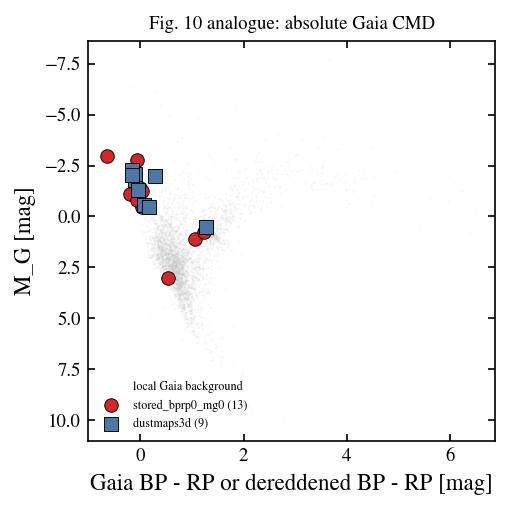

In [10]:
cmd_rows: list[dict[str, object]] = []
for _, row in cohort.iterrows():
    coords = dustmaps_cmd_from_fields(
        g_mag=row.get("phot_g_mean_mag"),
        bp_rp=row.get("bp_rp"),
        dist_pc=row.get("distance_gspphot"),
        a_v_3d=row.get("A_v_3d"),
        bp_mag=row.get("phot_bp_mean_mag"),
        rp_mag=row.get("phot_rp_mean_mag"),
        parallax_mas=row.get("parallax"),
    )
    cmd_rows.append(coords)
cmd = pd.DataFrame(cmd_rows, index=cohort.index)
cohort_cmd = pd.concat([cohort.copy(), cmd.add_prefix("cmd_")], axis=1)

stored_color = numeric(cohort_cmd, "bprp0")
stored_mag = numeric(cohort_cmd, "mg0")
fallback_color = numeric(cohort_cmd, "cmd_cmd_color")
fallback_mag = numeric(cohort_cmd, "cmd_cmd_mag")
cohort_cmd["abs_cmd_color"] = stored_color.where(np.isfinite(stored_color), fallback_color)
cohort_cmd["abs_cmd_mag"] = stored_mag.where(np.isfinite(stored_mag), fallback_mag)
cohort_cmd["abs_cmd_source"] = np.where(np.isfinite(stored_color) & np.isfinite(stored_mag), "stored_bprp0_mg0", cohort_cmd["cmd_cmd_coordinate_source"])

fig, ax = plt.subplots(figsize=FIG_SINGLE_COL_SQUARE)
bg_abs = bg.copy()
if {"bp_rp", "phot_g_mean_mag", "parallax"}.issubset(bg_abs.columns):
    plx = pd.to_numeric(bg_abs["parallax"], errors="coerce")
    bg_g = pd.to_numeric(bg_abs["phot_g_mean_mag"], errors="coerce")
    bg_c = pd.to_numeric(bg_abs["bp_rp"], errors="coerce")
    ok_bg = np.isfinite(plx) & (plx > 0) & np.isfinite(bg_g) & np.isfinite(bg_c)
    bg_mg = bg_g + 5.0 * np.log10(plx / 1000.0) + 5.0
    ok_bg &= np.isfinite(bg_mg)
    ax.scatter(bg_c[ok_bg], bg_mg[ok_bg], s=1.0, c="0.75", alpha=0.12, edgecolors="none", rasterized=True, label="local Gaia background")

ok = np.isfinite(cohort_cmd["abs_cmd_color"]) & np.isfinite(cohort_cmd["abs_cmd_mag"])
for source, marker, face in [("stored_bprp0_mg0", "o", "#D62728"), ("dustmaps3d", "s", "#4C78A8"), ("observed_no_extinction", "^", "#54A24B"), ("observed_fallback", "o", "none")]:
    part = cohort_cmd[ok & cohort_cmd["abs_cmd_source"].astype(str).eq(source)]
    if part.empty:
        continue
    if face == "none":
        ax.scatter(part["abs_cmd_color"], part["abs_cmd_mag"], s=42, marker=marker, facecolors="none", edgecolors="#D62728", linewidths=0.8, label=f"{source} ({len(part)})")
    else:
        ax.scatter(part["abs_cmd_color"], part["abs_cmd_mag"], s=42, marker=marker, c=face, edgecolors="black", linewidths=0.45, label=f"{source} ({len(part)})")
remaining = cohort_cmd[ok & ~cohort_cmd["abs_cmd_source"].astype(str).isin({"stored_bprp0_mg0", "dustmaps3d", "observed_no_extinction", "observed_fallback"})]
if not remaining.empty:
    ax.scatter(remaining["abs_cmd_color"], remaining["abs_cmd_mag"], s=42, c="#9467BD", edgecolors="black", linewidths=0.45, label=f"other ({len(remaining)})")
ax.invert_yaxis()
ax.set_xlabel("Gaia BP - RP or dereddened BP - RP [mag]")
ax.set_ylabel("M_G [mag]")
ax.set_title("Fig. 10 analogue: absolute Gaia CMD", fontsize=9)
ax.legend(frameon=False, fontsize=5.8, loc="lower left")
ax.tick_params(direction="in", top=True, right=True)
show_inline(
    fig,
    "Fig. 10 analogue",
    status="partial_good_analog",
    data_source="stored mg/mg0/bprp0 plus dustmaps_cmd_from_fields fallback",
    caveat="No Gaia Level-1 source/lens blend split and no Bailer-Jones distance-cache parity with the paper.",
    n_rows=int(ok.sum()),
)


## Always-run microlensing fit pass


In [11]:
candidate_ids = cohort["candidate_id"].astype(str).tolist()
print(f"Running microlensing fits for {len(candidate_ids)} July 1 candidate IDs with FIT_WORKERS={FIT_WORKERS} ...")
fit_df, fit_results = fit_microlensing_candidates(
    DB_PATH,
    candidate_ids=candidate_ids,
    fit_workers=FIT_WORKERS,
    prefer_g_band=True,
    show_progress=True,
    progress_desc="July 1 microlensing fits",
)
fit_df = fit_df.sort_values("candidate_id").reset_index(drop=True)
fit_by_candidate = {str(result.get("summary", {}).get("candidate_id")): result for result in fit_results}
SUMMARY["n_fit_rows"] = int(len(fit_df))
print(f"Fit result rows: {len(fit_df)}")
fit_cols = [
    "candidate_id", "band_used", "n_points_total", "fit_ok", "best_model", "best_model_by_bic",
    "fit_t0_jd", "fit_t0_jd_minus_2450000", "pipeline_jump_t0", "raw_paczynski_tE_days",
    "reported_tE_days", "paczynski_reduced_chi2", "fit_reduced_chi2",
    "delta_bic_vs_flat", "delta_bic_vs_best_alt", "fit_warning",
]
display(compact_columns(fit_df, fit_cols))


Running microlensing fits for 22 July 1 candidate IDs with FIT_WORKERS=1 ...


RuntimeError: SED ledger writes require SQLite foreign-key enforcement; open the database with malca.review.store.db_connect()

## Fit-dependent analogues


In [ ]:
fig, ax = plt.subplots(figsize=FIG_SINGLE_COL_MEDIUM)
fit_t0 = jd_minus_2450000(fit_df["fit_t0_jd"] if "fit_t0_jd" in fit_df.columns else fit_df.get("fit_t0_jd_minus_2450000", pd.Series(dtype=float))).dropna()
jump_t0 = jd_minus_2450000(cohort["jump_best_t0"]).dropna()
all_t0 = pd.concat([fit_t0, jump_t0]).dropna()
if all_t0.empty:
    bins = np.linspace(5000, 9000, 20)
else:
    lo = np.floor(float(all_t0.min()) / 100.0) * 100.0
    hi = np.ceil(float(all_t0.max()) / 100.0) * 100.0
    bins = np.linspace(lo, hi, 24)
ax.hist(jump_t0, bins=bins, histtype="stepfilled", color="0.8", edgecolor="0.45", alpha=0.85, label="DB jump_best_t0 proxy")
ax.hist(fit_t0, bins=bins, histtype="step", color="#D62728", linewidth=1.6, label="Paczynski fit t0")
ax.set_xlabel("Event epoch [JD - 2450000]")
ax.set_ylabel("Candidates")
ax.set_title("Fig. 4 analogue: event-time distribution", fontsize=9)
ax.legend(frameon=False, fontsize=7)
ax.tick_params(direction="in", top=True, right=True)
show_inline(
    fig,
    "Fig. 4 analogue",
    status="fit_dependent_analog",
    data_source="fit_t0_jd plus review.db jump_best_t0 proxy",
    caveat="Fit t0 is MALCA/ASAS-SN Paczynski t0, not Gaia paczynski0_tmax.",
    n_rows=int(fit_t0.notna().sum()),
)


In [ ]:
fig, ax = plt.subplots(figsize=FIG_SINGLE_COL_MEDIUM)
te = pd.to_numeric(fit_df.get("raw_paczynski_tE_days", pd.Series(dtype=float)), errors="coerce")
te = te[np.isfinite(te) & (te > 0)]
if te.empty:
    bins = np.logspace(0, 3, 20)
else:
    low = max(0.5, float(np.nanpercentile(te, 1.0)) * 0.8)
    high = max(low * 5.0, float(np.nanpercentile(te, 99.0)) * 1.25)
    bins = np.logspace(np.log10(low), np.log10(high), 24)
ax.hist(te, bins=bins, histtype="stepfilled", color="#4C78A8", alpha=0.75, edgecolor="black")
ax.set_xscale("log")
ax.set_xlabel("MALCA raw Paczynski t_E [days]")
ax.set_ylabel("Candidates")
ax.set_title("Fig. 6 analogue: fitted timescale distribution", fontsize=9)
ax.tick_params(direction="in", top=True, right=True)
show_inline(
    fig,
    "Fig. 6 analogue",
    status="fit_dependent_analog",
    data_source="fit_microlensing_candidates raw_paczynski_tE_days",
    caveat="Derived from ASAS-SN/MALCA fits; current DB microlens_te_days is empty and no Gaia paczynski columns exist.",
    n_rows=int(len(te)),
)


In [ ]:
fit_sky = cohort.merge(fit_df[["candidate_id", "raw_paczynski_tE_days", "best_model", "paczynski_reduced_chi2"]], on="candidate_id", how="left")
x, y = lb_to_mollweide(fit_sky["gal_l"], fit_sky["gal_b"])
te = pd.to_numeric(fit_sky["raw_paczynski_tE_days"], errors="coerce").to_numpy(dtype=float)
ok = np.isfinite(x) & np.isfinite(y) & np.isfinite(te) & (te > 0)
fig, ax = plt.subplots(figsize=(7.2, 3.8), subplot_kw={"projection": "mollweide"})
plot_optional_dust_background(ax)
if ok.any():
    norm = mcolors.LogNorm(vmin=max(float(np.nanmin(te[ok])), 0.1), vmax=float(np.nanmax(te[ok])))
    sc = ax.scatter(x[ok], y[ok], c=te[ok], cmap="viridis", norm=norm, s=48, edgecolors="black", linewidths=0.45, zorder=3)
    cbar = fig.colorbar(sc, ax=ax, orientation="horizontal", pad=0.10, shrink=0.65)
    cbar.set_label("MALCA raw Paczynski t_E [days]")
missing = np.isfinite(x) & np.isfinite(y) & ~ok
if missing.any():
    ax.scatter(x[missing], y[missing], c="0.5", marker="x", s=38, zorder=3, label="missing t_E")
add_mollweide_grid(ax)
ax.set_title("Fig. 11 analogue: sky map colored by fitted timescale", fontsize=9)
if missing.any():
    ax.legend(frameon=False, fontsize=7, loc="lower left")
show_inline(
    fig,
    "Fig. 11 analogue",
    status="fit_dependent_analog",
    data_source="review.db coordinates plus raw_paczynski_tE_days",
    caveat="MALCA/ASAS-SN fitted timescale, not Gaia Level-1 timescale.",
    n_rows=int(ok.sum()),
)


In [ ]:
bin_defs = [
    ("inner bulge-like\n|l| < 5 deg", lambda df: df["l_wrapped_deg"].abs() < 5.0),
    ("outer bulge-like\n5 <= |l| < 10 deg", lambda df: (df["l_wrapped_deg"].abs() >= 5.0) & (df["l_wrapped_deg"].abs() < 10.0)),
    ("disk/field-like\n|l| >= 10 deg", lambda df: df["l_wrapped_deg"].abs() >= 10.0),
]
work = fit_sky.copy()
work["l_wrapped_deg"] = wrap_l_180(work["gal_l"])
work["raw_paczynski_tE_days"] = pd.to_numeric(work["raw_paczynski_tE_days"], errors="coerce")
all_te = work.loc[np.isfinite(work["raw_paczynski_tE_days"]) & (work["raw_paczynski_tE_days"] > 0), "raw_paczynski_tE_days"]
if all_te.empty:
    bins = np.logspace(0, 3, 18)
else:
    bins = np.logspace(np.log10(max(0.5, float(all_te.min()) * 0.8)), np.log10(max(float(all_te.max()) * 1.25, 5.0)), 18)

fig, axes = plt.subplots(1, 3, figsize=(8.0, 2.9), sharey=True)
for ax, (label, mask_func) in zip(axes, bin_defs):
    part = work[mask_func(work)].copy()
    vals = part.loc[np.isfinite(part["raw_paczynski_tE_days"]) & (part["raw_paczynski_tE_days"] > 0), "raw_paczynski_tE_days"]
    if vals.empty:
        ax.text(0.5, 0.5, "no objects", transform=ax.transAxes, ha="center", va="center", fontsize=8)
    else:
        ax.hist(vals, bins=bins, histtype="stepfilled", color="#4C78A8", alpha=0.7, edgecolor="black")
        if len(vals) >= 3:
            logv = np.log10(vals.to_numpy(dtype=float))
            mu = float(np.nanmean(logv))
            sigma = float(np.nanstd(logv, ddof=1))
            if np.isfinite(sigma) and sigma > 0:
                centers = np.sqrt(bins[:-1] * bins[1:])
                width = np.diff(np.log10(bins))
                density = np.exp(-0.5 * ((np.log10(centers) - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))
                y_model = density * len(vals) * width
                ax.plot(centers, y_model, color="#D62728", linewidth=1.3, label="Gaussian in log t_E")
                ax.legend(frameon=False, fontsize=6)
        else:
            ax.text(0.5, 0.86, "underpopulated", transform=ax.transAxes, ha="center", va="top", fontsize=7)
    ax.set_xscale("log")
    ax.set_title(f"{label}\nn={len(vals)}", fontsize=8)
    ax.set_xlabel("t_E [days]")
    ax.tick_params(direction="in", top=True, right=True)
axes[0].set_ylabel("Candidates")
fig.suptitle("Fig. 12 analogue: timescale distributions by Galactic longitude bin", fontsize=9)
show_inline(
    fig,
    "Fig. 12 analogue",
    status="fit_dependent_low_power_analog",
    data_source="raw_paczynski_tE_days split by gal_l",
    caveat="Technically rendered, but scientifically weak with 21 objects and no |l| < 10 deg bulge subset.",
    n_rows=int(len(all_te)),
)


## Figs. 17-21 analogues: model/residual and raw external panels


In [ ]:
fit_rank = fit_df.copy()
fit_rank["raw_paczynski_tE_days"] = pd.to_numeric(fit_rank.get("raw_paczynski_tE_days"), errors="coerce")
fit_rank["paczynski_reduced_chi2"] = pd.to_numeric(fit_rank.get("paczynski_reduced_chi2"), errors="coerce")
fit_rank = fit_rank.merge(cohort[["candidate_id", "n_external_sources"]], on="candidate_id", how="left")
fit_rank["fit_ok_sort"] = fit_rank.get("fit_ok", False).astype(bool).astype(int)
fit_rank["external_sort"] = pd.to_numeric(fit_rank["n_external_sources"], errors="coerce").fillna(0)
fit_rank["chi_sort"] = fit_rank["paczynski_reduced_chi2"].where(np.isfinite(fit_rank["paczynski_reduced_chi2"]), np.inf)
example_ids = (
    fit_rank[np.isfinite(fit_rank["raw_paczynski_tE_days"]) & (fit_rank["raw_paczynski_tE_days"] > 0)]
    .sort_values(["fit_ok_sort", "external_sort", "chi_sort"], ascending=[False, False, True])
    .head(5)["candidate_id"]
    .astype(str)
    .tolist()
)
if len(example_ids) < 5:
    for cid in fit_rank.sort_values(["external_sort", "chi_sort"], ascending=[False, True])["candidate_id"].astype(str):
        if cid not in example_ids:
            example_ids.append(cid)
        if len(example_ids) >= 5:
            break

print("Representative model/residual example IDs:", example_ids)
for i, cid in enumerate(example_ids, start=17):
    result = fit_by_candidate.get(cid)
    if result is None:
        print(f"Skipping {cid}: no fit result")
        continue
    fig, _axes = plot_candidate_fit(result)
    fig.suptitle(f"Fig. {i} analogue: {cid} MALCA ASAS-SN fit/residual panel", fontsize=10, y=0.995)
    record_figure(
        f"Fig. {i} model/residual analogue",
        "fit_dependent_analog",
        "plot_candidate_fit output from fit_microlensing_candidates",
        "ASAS-SN/MALCA Paczynski/Gaussian/FRED/flat panel, not Gaia BP/RP/G + OGLE/GSA/MulensModel.",
        1,
    )
    fig.tight_layout()
    plt.show()

In [ ]:
from io import BytesIO


MULTISOURCE_PAPER_FIG_DIR = RESULTS_DIR / "microlensing_paper_analogues"
if EXPORT_PAPER_FIGURES:
    MULTISOURCE_PAPER_FIG_DIR.mkdir(parents=True, exist_ok=True)
MULTISOURCE_INLINE_DPI = 320
MULTISOURCE_PAPER_FIGURES: list[dict[str, object]] = []


def external_time_to_jd_minus_offset(values: pd.Series, jd_system: str) -> pd.Series:
    vals = pd.to_numeric(values, errors="coerce")
    system = str(jd_system or "mjd").strip().lower()
    if system == "mjd":
        jd = vals + MJD_TO_JD
    elif system == "btjd":
        jd = vals + TESS_BTJD_OFFSET
    elif system == "bkjd":
        jd = vals + KEPLER_BKJD_OFFSET
    elif system == "bjd_gaia":
        jd = vals + GAIA_TCB_EPOCH_JD
    else:
        finite = vals[np.isfinite(vals)]
        if not finite.empty and float(finite.median()) > 2_000_000.0:
            jd = vals
        elif not finite.empty and float(finite.median()) > 10_000.0:
            jd = vals + MJD_TO_JD
        else:
            jd = vals
    return as_full_jd(jd) - JD_OFFSET


LOCAL_BAND_COLORS = {
    "g": "#238b45",
    "V": "#6a51a3",
    "B": "#2171b5",
    "r": "#cb181d",
    "i": "#d94801",
    "z": "#8c6d31",
    "all": "#252525",
}
SOURCE_AXIS_COLORS = {
    "asassn": "#238b45",
    "ztf": "#dd4444",
    "ps1": "#8844cc",
    "neowise": "#ff8c42",
    "gaia_epoch": "#b58900",
    "crts": "#666666",
}
SOURCE_MARKERS = {
    "asassn": "o",
    "ztf": "^",
    "ps1": "*",
    "neowise": "x",
    "gaia_epoch": "P",
    "crts": "s",
}


def candidate_event_time_jd_minus_offset(candidate_id: str) -> float:
    cid = str(candidate_id)
    result = fit_by_candidate.get(cid)
    if result is not None:
        best_seed = result.get("best_seed_result", {}) or {}
        pac = best_seed.get("fits", {}).get("paczynski", {}) or {}
        params = pac.get("params")
        if pac.get("success") and params is not None and len(params) >= 2:
            t0 = as_full_jd(pd.Series([params[1]])).iloc[0]
            if np.isfinite(t0):
                return float(t0 - JD_OFFSET)
    if "fit_t0_jd" in fit_df.columns:
        row = fit_df[fit_df["candidate_id"].astype(str).eq(cid)]
        if not row.empty:
            t0 = as_full_jd(row["fit_t0_jd"]).iloc[0]
            if np.isfinite(t0):
                return float(t0 - JD_OFFSET)
    row = cohort[cohort["candidate_id"].astype(str).eq(cid)]
    if not row.empty:
        t0 = as_full_jd(row["jump_best_t0"]).iloc[0]
        if np.isfinite(t0):
            return float(t0 - JD_OFFSET)
    return np.nan


def asassn_overlay_payload(candidate_id: str, path: Path) -> dict[str, object] | None:
    try:
        lc = load_lightcurve(path)
        df_lc = filter_lightcurve(lc, max_error=1.0)
    except Exception as exc:
        print(f"{candidate_id}: ASAS-SN unavailable: {exc}")
        return None
    if df_lc.empty:
        return None

    x = jd_minus_display_offset(df_lc["time"])
    series: list[dict[str, object]] = []
    for band in sorted(df_lc["band"].dropna().astype(str).unique()):
        part = df_lc[df_lc["band"].astype(str).eq(band)].copy()
        x_part = x.loc[part.index]
        y = pd.to_numeric(part["value"], errors="coerce")
        err = pd.to_numeric(part["value_error"], errors="coerce")
        ok = np.isfinite(x_part) & np.isfinite(y)
        if not ok.any():
            continue
        order = np.argsort(x_part[ok].to_numpy(dtype=float))
        x_vals = x_part[ok].to_numpy(dtype=float)[order]
        y_vals = y[ok].to_numpy(dtype=float)[order]
        err_vals = err[ok].to_numpy(dtype=float)[order]
        baseline = float(np.nanmedian(y_vals))
        if not np.isfinite(baseline):
            continue
        series.append(
            {
                "x": x_vals,
                "y": y_vals - baseline,
                "err": err_vals,
                "label": f"ASAS-SN {band}",
                "color": LOCAL_BAND_COLORS.get(str(band), SOURCE_AXIS_COLORS["asassn"]),
                "marker": "o",
                "baseline_mag": baseline,
            }
        )
    if not series:
        return None
    return {
        "source": "asassn",
        "axis_label": "ASAS-SN [mag]",
        "axis_color": SOURCE_AXIS_COLORS["asassn"],
        "invert_y": True,
        "series": series,
    }


def external_overlay_payload(source: str, path: Path) -> dict[str, object] | None:
    spec = EXTERNAL_LC_SPECS.get(source, {})
    df = load_external_lc_frame(source, Path(path))
    if df.empty or not spec:
        return None
    if bool(spec.get("is_flux", False)):
        return None

    col_lookup = {str(col).lower(): col for col in df.columns}
    time_col = col_lookup.get(str(spec.get("time_col", "")).lower())
    if time_col is None:
        print(f"{source}: missing time column")
        return None
    x = external_time_to_jd_minus_offset(df[time_col], str(spec.get("jd_system", "mjd")))
    filter_col = spec.get("filter_col")
    actual_filter = col_lookup.get(str(filter_col).lower()) if filter_col else None
    bands = spec.get("bands") or {
        source: {
            "label": EXTERNAL_SOURCE_LABELS.get(source, source),
            "mag_col": spec.get("mag_col"),
            "err_col": spec.get("err_col"),
        }
    }

    series: list[dict[str, object]] = []
    for band_key, band_info in bands.items():
        mag_col = col_lookup.get(str(band_info.get("mag_col") or spec.get("mag_col", "")).lower())
        err_col = col_lookup.get(str(band_info.get("err_col") or spec.get("err_col", "")).lower())
        if mag_col is None:
            continue
        sub = df.copy()
        x_sub = x.copy()
        if actual_filter is not None:
            mask_band = sub[actual_filter].astype(str).str.lower().eq(str(band_key).lower())
            sub = sub.loc[mask_band]
            x_sub = x_sub.loc[sub.index]
        y = pd.to_numeric(sub[mag_col], errors="coerce")
        err = pd.to_numeric(sub[err_col], errors="coerce") if err_col is not None else pd.Series(np.nan, index=sub.index)
        ok = np.isfinite(x_sub) & np.isfinite(y)
        if not ok.any():
            continue
        order = np.argsort(x_sub[ok].to_numpy(dtype=float))
        x_vals = x_sub[ok].to_numpy(dtype=float)[order]
        y_vals = y[ok].to_numpy(dtype=float)[order]
        err_vals = err[ok].to_numpy(dtype=float)[order]
        baseline = float(np.nanmedian(y_vals))
        if not np.isfinite(baseline):
            continue
        series.append(
            {
                "x": x_vals,
                "y": y_vals - baseline,
                "err": err_vals,
                "label": str(band_info.get("label") or band_key),
                "color": str(band_info.get("color") or SOURCE_AXIS_COLORS.get(source, "0.25")),
                "marker": SOURCE_MARKERS.get(source, "o"),
                "baseline_mag": baseline,
            }
        )
    if not series:
        return None

    is_flux = bool(spec.get("is_flux", False))
    label = EXTERNAL_SOURCE_LABELS.get(source, source)
    return {
        "source": source,
        "axis_label": f"{label} [{'flux' if is_flux else 'mag'}]",
        "axis_color": SOURCE_AXIS_COLORS.get(source, series[0]["color"]),
        "invert_y": not is_flux,
        "series": series,
    }


def relative_magnitude_limits(values: list[np.ndarray]) -> tuple[float, float] | None:
    if not values:
        return None
    arr = np.concatenate([np.asarray(v, dtype=float) for v in values])
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return None
    span = float(np.nanpercentile(np.abs(arr), 99.0))
    if not np.isfinite(span) or span <= 0:
        spread = float(np.nanstd(arr))
        span = 4.0 * spread if np.isfinite(spread) and spread > 0 else 0.0
    span = max(1.15 * span, 0.05)
    return float(span), float(-span)


def multisource_overlay_payloads(candidate_id: str) -> list[dict[str, object]]:
    row = cohort.loc[cohort["candidate_id"].astype(str).eq(str(candidate_id))].iloc[0]
    payloads: list[dict[str, object]] = []
    asassn_path = row.get("local_lc_path")
    if asassn_path is not None and Path(asassn_path).exists():
        payload = asassn_overlay_payload(str(candidate_id), Path(asassn_path))
        if payload is not None:
            payloads.append(payload)

    ext = manifest[manifest["candidate_id"].astype(str).eq(str(candidate_id))].copy()
    ext = ext[ext["source"].isin(EXTERNAL_SOURCES)].copy()
    source_order = {source: i for i, source in enumerate(EXTERNAL_SOURCES)}
    ext["_source_order"] = ext["source"].map(source_order).fillna(999).astype(int)
    for row_ext in ext.sort_values(["_source_order", "source"]).itertuples(index=False):
        payload = external_overlay_payload(str(row_ext.source), Path(str(row_ext.path)))
        if payload is not None:
            payloads.append(payload)
    return payloads


def plot_raw_multisurvey_overlay(
    candidate_id: str,
    *,
    figsize: tuple[float, float] = (14.0, 5.80),
    title_prefix: str = "Median-aligned multi-survey light curves",
    marker_size: float = 2.0,
) -> tuple[plt.Figure, int, float]:
    payloads = multisource_overlay_payloads(str(candidate_id))
    fig, host = plt.subplots(figsize=figsize)
    layout_right = 0.98
    if not payloads:
        host.text(0.5, 0.5, f"{candidate_id}: no plottable light curves", transform=host.transAxes, ha="center", va="center", fontsize=8)
        host.set_axis_off()
        return fig, 0, layout_right

    handles = []
    labels = []
    all_x: list[np.ndarray] = []
    all_y: list[np.ndarray] = []
    total_points = 0
    for payload in payloads:
        for series in payload["series"]:
            xx = np.asarray(series["x"], dtype=float)
            yy = np.asarray(series["y"], dtype=float)
            ee = np.asarray(series["err"], dtype=float)
            ok = np.isfinite(xx) & np.isfinite(yy)
            if not ok.any():
                continue
            xx = xx[ok]
            yy = yy[ok]
            ee = ee[ok] if ee.shape == ok.shape else np.full_like(yy, np.nan, dtype=float)
            finite_err = np.isfinite(ee) & (ee > 0)
            all_x.append(xx)
            all_y.append(yy)
            total_points += int(ok.sum())
            if finite_err.any() and len(xx) <= 2500:
                artist = host.errorbar(
                    xx,
                    yy,
                    yerr=np.where(finite_err, ee, np.nan),
                    fmt=str(series["marker"]),
                    linestyle="none",
                    markersize=marker_size,
                    markeredgecolor="0.15",
                    markeredgewidth=0.25,
                    color=str(series["color"]),
                    ecolor=str(series["color"]),
                    elinewidth=0.45,
                    capsize=0,
                    alpha=0.80,
                    label=str(series["label"]),
                )
            else:
                artist = host.scatter(
                    xx,
                    yy,
                    s=marker_size**2,
                    marker=str(series["marker"]),
                    color=str(series["color"]),
                    edgecolors="0.15" if str(series["marker"]) not in {"x", "+"} else "none",
                    linewidths=0.25,
                    alpha=0.78,
                    label=str(series["label"]),
                )
            handles.append(artist)
            labels.append(str(series["label"]))

    zero_line = host.axhline(0.0, color="0.25", linestyle=":", linewidth=0.8, label="source/band median", zorder=1)
    handles.insert(0, zero_line)
    labels.insert(0, "source/band median")

    event_t = candidate_event_time_jd_minus_offset(str(candidate_id))
    if np.isfinite(event_t):
        line = host.axvline(event_t, color="0.15", linestyle="--", linewidth=0.8, label="fit/event epoch", zorder=1)
        handles.insert(0, line)
        labels.insert(0, "fit/event epoch")

    if all_x:
        x_all = np.concatenate(all_x)
        x_all = x_all[np.isfinite(x_all)]
        if x_all.size:
            lo, hi = float(np.nanmin(x_all)), float(np.nanmax(x_all))
            pad = max(0.03 * (hi - lo), 25.0)
            host.set_xlim(lo - pad, hi + pad)
    limits = relative_magnitude_limits(all_y)
    if limits is not None:
        host.set_ylim(*limits)

    host.set_xlabel(f"Time [JD - {int(JD_OFFSET)}]")
    host.set_ylabel(r"Relative magnitude, $m - \tilde{m}$ [mag]")
    host.set_title(f"{title_prefix}: {candidate_id}", fontsize=10, pad=8)
    host.grid(True, axis="both", color="0.86", linewidth=0.55)
    host.tick_params(which="both", direction="in", top=True, right=True, labelsize=8)
    host.legend(handles, labels, frameon=False, fontsize=5.4, loc="upper center", bbox_to_anchor=(0.5, -0.13), borderpad=0.0, handlelength=1.0, ncol=6)
    fig.subplots_adjust(right=layout_right, top=0.88, bottom=0.24)
    return fig, total_points, layout_right


def show_multisource_overlay(
    fig,
    figure: str,
    *,
    name: str,
    caption: str,
    status: str,
    data_source: str,
    caveat: str,
    n_rows: int | None,
    layout_right: float,
) -> None:
    pdf_path = MULTISOURCE_PAPER_FIG_DIR / f"{name}.pdf" if EXPORT_PAPER_FIGURES else None
    png_path = MULTISOURCE_PAPER_FIG_DIR / f"{name}.png" if EXPORT_PAPER_FIGURES else None
    record_figure(figure, status, data_source, caveat, n_rows)
    fig.tight_layout(rect=(0.0, 0.12, layout_right, 0.94))
    if EXPORT_PAPER_FIGURES:
        MULTISOURCE_PAPER_FIG_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(pdf_path, dpi=300, bbox_inches=None, facecolor="white")
        fig.savefig(png_path, dpi=320, bbox_inches=None, facecolor="white")
    record = {
        "name": name,
        "pdf": str(pdf_path.relative_to(REPO_ROOT)) if pdf_path else None,
        "png": str(png_path.relative_to(REPO_ROOT)) if png_path else None,
        "caption": caption,
        "data_source": data_source,
        "caveat": caveat,
        "n_rows": n_rows,
    }
    MULTISOURCE_PAPER_FIGURES.append(record)
    png_buffer = BytesIO()
    fig.savefig(png_buffer, format="png", dpi=MULTISOURCE_INLINE_DPI, bbox_inches=None, facecolor="white")
    display(DisplayImage(data=png_buffer.getvalue()))
    plt.close(fig)


external_example_ids = cohort["candidate_id"].astype(str).tolist()
print(f"Plotting raw external overlays for all {len(external_example_ids)} microlensing candidates:", external_example_ids)
for offset, cid in enumerate(external_example_ids, start=17):
    fig, n_points, layout_right = plot_raw_multisurvey_overlay(cid)
    show_multisource_overlay(
        fig,
        f"Raw external LC overlay: {cid}",
        name=f"paper_fig{offset:02d}_multisource_overlay_{cid}",
        caption=f"Fig. {offset} analogue. Multi-survey light curve for {cid}, with non-TESS magnitude survey sources median-aligned on a common absolute time axis.",
        status="ready_raw_lc_analog",
        data_source=f"bundled ASAS-SN plus cached non-TESS external_lc_manifest parquet files, all converted to JD - {int(JD_OFFSET)}",
        caveat="One candidate per figure; TESS is omitted and every source/band is median-subtracted so zero points align and morphology drives the comparison.",
        n_rows=n_points,
        layout_right=layout_right,
    )

## Publication Figures

Compact A&A-style exports for the July 1 microlensing analogues. These cells intentionally keep the exploratory plots above unchanged and write the polished versions under `results/microlensing_paper_analogues/`.


In [ ]:
from io import BytesIO

from IPython.display import Image as DisplayImage
from matplotlib.colors import LogNorm
from matplotlib.ticker import AutoMinorLocator, LogLocator, MaxNLocator, ScalarFormatter
from scipy.ndimage import gaussian_filter

from malca.plotting.lightcurve_publication import (
    FIG_SINGLE_COL_WIDTH,
    FIG_TWO_COL_WIDTH,
    finalize_publication_figure,
)
from scripts.microlensing import _evaluate_model

PAPER_FIG_DIR = RESULTS_DIR / "microlensing_paper_analogues"
if EXPORT_PAPER_FIGURES:
    PAPER_FIG_DIR.mkdir(parents=True, exist_ok=True)
PAPER_FIGURES: list[dict[str, object]] = []
PAPER_INLINE_DPI = 220
FIG_TWO_COL_SHORT = (FIG_TWO_COL_WIDTH, 3.0)

PAPER_STYLE = {
    "font.size": 7.5,
    "axes.labelsize": 8.0,
    "axes.titlesize": 8.0,
    "xtick.labelsize": 7.0,
    "ytick.labelsize": 7.0,
    "legend.fontsize": 6.5,
    "axes.linewidth": 0.75,
    "xtick.major.width": 0.75,
    "ytick.major.width": 0.75,
    "xtick.minor.width": 0.55,
    "ytick.minor.width": 0.55,
    "xtick.major.size": 3.2,
    "ytick.major.size": 3.2,
    "xtick.minor.size": 1.7,
    "ytick.minor.size": 1.7,
    "legend.frameon": True,
    "legend.fancybox": False,
    "legend.framealpha": 1.0,
    "savefig.facecolor": "white",
    "figure.facecolor": "white",
}


def paper_style() -> None:
    apply_publication_rcparams(plt)
    plt.rcParams.update(PAPER_STYLE)


def paper_axes(ax, *, minor: bool = True, grid: bool = False) -> None:
    ax.tick_params(which="both", direction="in", top=True, right=True)
    if minor:
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator())
    if grid:
        ax.grid(True, color="0.82", linewidth=0.45, alpha=0.9)


def paper_two_column_axes(ax, *, minor: bool = True, grid: bool = False) -> None:
    paper_axes(ax, minor=minor, grid=grid)
    ax.xaxis.label.set_size(11.0)
    ax.yaxis.label.set_size(11.0)
    ax.tick_params(which="major", labelsize=9.5, length=4.8, width=0.9)
    ax.tick_params(which="minor", length=2.6, width=0.7)
    for spine in ax.spines.values():
        spine.set_linewidth(0.9)


def show_paper_figure(
    fig,
    name: str,
    *,
    caption: str,
    data_source: str,
    caveat: str,
    n_rows: int | None = None,
    pad: float = 0.22,
    rect: tuple[float, float, float, float] | None = None,
) -> dict[str, object]:
    pdf_path = PAPER_FIG_DIR / f"{name}.pdf" if EXPORT_PAPER_FIGURES else None
    png_path = PAPER_FIG_DIR / f"{name}.png" if EXPORT_PAPER_FIGURES else None
    finalize_publication_figure(fig, pad=pad, rect=rect)
    if EXPORT_PAPER_FIGURES:
        PAPER_FIG_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(pdf_path, dpi=300, bbox_inches=None, facecolor="white")
        fig.savefig(png_path, dpi=320, bbox_inches=None, facecolor="white")
    record = {
        "name": name,
        "pdf": str(pdf_path.relative_to(REPO_ROOT)) if pdf_path else None,
        "png": str(png_path.relative_to(REPO_ROOT)) if png_path else None,
        "caption": caption,
        "data_source": data_source,
        "caveat": caveat,
        "n_rows": n_rows,
    }
    PAPER_FIGURES.append(record)
    FIGURE_SUMMARY.append(
        {
            "figure": name,
            "status": "publication_export" if EXPORT_PAPER_FIGURES else "publication_inline",
            "data_source": data_source,
            "caveat": caveat,
            "n_rows": n_rows,
        }
    )
    png_buffer = BytesIO()
    fig.savefig(png_buffer, format="png", dpi=PAPER_INLINE_DPI, bbox_inches=None, facecolor="white")
    display(DisplayImage(data=png_buffer.getvalue()))
    plt.close(fig)
    return record


def hist_with_poisson(ax, values, bins, *, color: str, label: str, alpha: float = 0.35, filled: bool = True):
    arr = pd.to_numeric(pd.Series(values), errors="coerce")
    arr = arr[np.isfinite(arr)]
    histtype = "stepfilled" if filled else "step"
    counts, edges, _patches = ax.hist(
        arr,
        bins=bins,
        histtype=histtype,
        color=color,
        alpha=alpha if filled else 1.0,
        edgecolor=color,
        linewidth=0.9,
        label=label,
    )
    centers = 0.5 * (edges[:-1] + edges[1:])
    ok = counts > 0
    if ok.any():
        ax.errorbar(
            centers[ok],
            counts[ok],
            yerr=np.sqrt(counts[ok]),
            fmt="none",
            ecolor=color,
            elinewidth=0.55,
            capsize=1.0,
            capthick=0.55,
            alpha=0.9,
            zorder=4,
        )
    ax.yaxis.set_major_locator(MaxNLocator(integer=True, min_n_ticks=3))
    return counts, edges


def fit_t0_series() -> pd.Series:
    if "fit_t0_jd" in fit_df.columns:
        return jd_minus_2450000(fit_df["fit_t0_jd"])
    return jd_minus_2450000(fit_df.get("fit_t0_jd_minus_2450000", pd.Series(dtype=float)))


def fitted_te_series() -> pd.Series:
    te = pd.to_numeric(fit_df.get("raw_paczynski_tE_days", pd.Series(dtype=float)), errors="coerce")
    return te[np.isfinite(te) & (te > 0)]


def paper_caption(label: str, text: str) -> str:
    return f"{label}. {text}"

plt.close("all")
paper_style()
print("Paper-quality figures render inline in the notebook.")
if EXPORT_PAPER_FIGURES:
    print(f"Paper figure export directory: {PAPER_FIG_DIR.relative_to(REPO_ROOT)}")


In [ ]:
# Fig. 1 analogue: compact longitude/latitude histograms.
paper_style()
fig, axes = plt.subplots(2, 1, figsize=(FIG_SINGLE_COL_WIDTH, 3.9), sharex=False)

l_vals = pd.Series(wrap_l_180(cohort["gal_l"])).dropna()
b_vals = numeric(cohort, "gal_b").dropna()

hist_with_poisson(
    axes[0],
    l_vals,
    np.arange(-180, 181, 20),
    color="#1f77b4",
    label="_nolegend_",
    alpha=0.35,
)
axes[0].set_xlabel(r"$\ell$ [$^\circ$]")
axes[0].set_ylabel(r"N per $20^\circ$")
axes[0].set_xlim(180, -180)

hist_with_poisson(
    axes[1],
    b_vals,
    np.arange(-25, 26, 2.5),
    color="#d62728",
    label="_nolegend_",
    alpha=0.30,
)
axes[1].set_xlabel(r"$b$ [$^\circ$]")
axes[1].set_ylabel(r"N per $2.5^\circ$")
axes[1].set_xlim(25, -25)

for ax in axes:
    paper_axes(ax)

show_paper_figure(
    fig,
    "paper_fig01_galactic_coordinate_histograms",
    caption=paper_caption(
        "Fig. 1 analogue",
        "Distribution of event-class and morphology-labelled microlensing candidates in Galactic longitude and latitude."
    ),
    data_source="review.db candidates.gal_l/gal_b",
    caveat=f"Current {len(cohort)}-object review union; no Gaia Sample A/B/A+B split.",
    n_rows=len(cohort),
)


In [ ]:
# Fig. 2 analogue: compact sky-position Mollweide map.
paper_style()
fig, ax = plt.subplots(figsize=(FIG_TWO_COL_WIDTH, 3.45), subplot_kw={"projection": "mollweide"})
dust_ok = plot_optional_dust_background(ax)
x, y = lb_to_mollweide(cohort["gal_l"], cohort["gal_b"])
ok = np.isfinite(x) & np.isfinite(y)
ax.scatter(
    x[ok],
    y[ok],
    s=17,
    c="#d62728",
    edgecolors="black",
    linewidths=0.35,
    zorder=3,
    label="July 1 candidates",
)
ax.grid(True, alpha=0.32, linestyle="-", linewidth=0.45)
ax.set_xlabel("Galactic longitude")
ax.set_ylabel("Galactic latitude")
ax.legend(loc="lower left", bbox_to_anchor=(0.01, 0.02), borderpad=0.35, handlelength=1.0)

show_paper_figure(
    fig,
    "paper_fig02_sky_mollweide",
    caption=paper_caption(
        "Fig. 2 analogue",
        "Sky positions of July 1 MALCA microlensing candidates in Galactic coordinates."
    ),
    data_source="review.db coordinates" + (" with optional SFD dust background" if dust_ok else ""),
    caveat="Background is not the Gaia EDR3 all-sky map used in the reference paper.",
    n_rows=int(ok.sum()),
)


In [ ]:
# Figs. 4, 5, and 6 analogues: compact parameter histograms.
paper_style()

# Fig. 4 analogue: fitted event epoch and DB proxy.
fig, ax = plt.subplots(figsize=(FIG_SINGLE_COL_WIDTH, 2.15))
fit_t0 = fit_t0_series().dropna()
jump_t0 = jd_minus_2450000(cohort["jump_best_t0"]).dropna()
all_t0 = pd.concat([fit_t0, jump_t0]).dropna()
if all_t0.empty:
    t0_bins = np.linspace(6000, 11000, 20)
else:
    lo = np.floor(float(all_t0.min()) / 100.0) * 100.0
    hi = np.ceil(float(all_t0.max()) / 100.0) * 100.0
    t0_bins = np.linspace(lo, hi, 18)
hist_with_poisson(ax, jump_t0, t0_bins, color="0.45", label="jump_best_t0 proxy", alpha=0.20)
hist_with_poisson(ax, fit_t0, t0_bins, color="#d62728", label="MALCA Paczynski fit", alpha=0.0, filled=False)
ax.set_xlabel("Event epoch [JD - 2450000]")
ax.set_ylabel("N")
ax.legend(loc="upper left", borderpad=0.35, handlelength=1.4)
paper_axes(ax)
show_paper_figure(
    fig,
    "paper_fig04_event_epoch_histogram",
    caption=paper_caption("Fig. 4 analogue", "Distribution of fitted event epochs for the July 1 MALCA microlensing candidates."),
    data_source="fit_microlensing_candidates fit_t0_jd and review.db jump_best_t0",
    caveat="MALCA/ASAS-SN fitted epoch; not Gaia Level-0 paczynski0_tmax.",
    n_rows=int(fit_t0.notna().sum()),
)

# Fig. 5 analogue: baseline magnitude.
fig, ax = plt.subplots(figsize=(FIG_SINGLE_COL_WIDTH, 2.15))
base = numeric(cohort, "baseline_mag").dropna()
gaia_g = numeric(cohort, "phot_g_mean_mag").dropna()
mag_vals = pd.concat([base, gaia_g]).dropna()
mag_bins = np.linspace(np.floor(float(mag_vals.min()) * 2) / 2, np.ceil(float(mag_vals.max()) * 2) / 2, 14) if not mag_vals.empty else np.linspace(10, 16, 14)
hist_with_poisson(ax, base, mag_bins, color="#1f77b4", label="ASAS-SN baseline magnitude", alpha=0.25)
hist_with_poisson(ax, gaia_g, mag_bins, color="black", label="Gaia mean G", alpha=0.0, filled=False)
ax.set_xlabel("Magnitude [mag]")
ax.set_ylabel("N")
ax.legend(loc="upper left", borderpad=0.35, handlelength=1.4)
paper_axes(ax)
show_paper_figure(
    fig,
    "paper_fig05_baseline_magnitude_histogram",
    caption=paper_caption("Fig. 5 analogue", "Distribution of ASAS-SN baseline and Gaia mean magnitudes for the microlensing candidate union."),
    data_source="review.db baseline_mag and phot_g_mean_mag",
    caveat="Uses the ASAS-SN light-curve baseline magnitude and Gaia mean G; not Gaia paczynski0_g0.",
    n_rows=int(max(len(base), len(gaia_g))),
)

# Fig. 6 analogue: fitted timescale.
fig, ax = plt.subplots(figsize=(FIG_SINGLE_COL_WIDTH, 2.15))
te = fitted_te_series()
if te.empty:
    te_bins = np.logspace(0, 3, 16)
else:
    te_bins = np.logspace(
        np.log10(max(0.5, float(te.min()) * 0.75)),
        np.log10(max(5.0, float(te.max()) * 1.35)),
        16,
    )
hist_with_poisson(ax, te, te_bins, color="#1f77b4", label="_nolegend_", alpha=0.30)
ax.set_xscale("log")
ax.set_xlabel(r"$t_E$ [d]")
ax.set_ylabel("N")
paper_axes(ax, minor=False)
ax.xaxis.set_major_locator(LogLocator(base=10))
ax.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1))
show_paper_figure(
    fig,
    "paper_fig06_timescale_histogram",
    caption=paper_caption("Fig. 6 analogue", "Distribution of fitted timescales for the microlensing candidate union."),
    data_source="fit_microlensing_candidates raw_paczynski_tE_days",
    caveat="Derived from MALCA/ASAS-SN fits; the review DB has no Gaia paczynski* columns.",
    n_rows=int(len(te)),
)


In [ ]:
# Fig. 7 analogue: parallax versus Galactic longitude with RUWE split and error bars.
paper_style()
fig, ax = plt.subplots(figsize=FIG_TWO_COL_SHORT)
plot_df = cohort.copy()
plot_df["l_wrapped_deg"] = wrap_l_180(plot_df["gal_l"])
plot_df["parallax"] = numeric(plot_df, "parallax")
plot_df["parallax_error"] = numeric(plot_df, "parallax_error")
plot_df["ruwe"] = numeric(plot_df, "ruwe")
quality = plot_df["ruwe"] < 1.5

for mask, marker, color, label in [
    (quality, "o", "black", r"RUWE $< 1.5$"),
    (~quality, "s", "#ff00cc", r"RUWE $\geq 1.5$"),
]:
    part = plot_df[mask & np.isfinite(plot_df["l_wrapped_deg"]) & np.isfinite(plot_df["parallax"])]
    if part.empty:
        continue
    ax.errorbar(
        part["l_wrapped_deg"],
        part["parallax"],
        yerr=part["parallax_error"].where(np.isfinite(part["parallax_error"]), np.nan),
        fmt=marker,
        color=color,
        ecolor="0.55" if color == "black" else "#ff99dd",
        markersize=5.4,
        markeredgecolor=color,
        markerfacecolor=color,
        markeredgewidth=0.55,
        elinewidth=0.9,
        capsize=0.0,
        linestyle="none",
        label=f"{label} ({len(part)})",
        zorder=3 if color == "black" else 4,
    )
ax.axhline(0.0, color="0.45", linewidth=0.9)
ax.set_xlim(180, -180)
ax.set_xlabel(r"$\ell$ [$^\circ$]")
ax.set_ylabel(r"$\varpi$ [mas]")
ax.legend(loc="upper left", fontsize=9.0, borderpad=0.45, handlelength=1.1, labelspacing=0.35)
paper_two_column_axes(ax)
show_paper_figure(
    fig,
    "paper_fig07_parallax_longitude",
    caption=paper_caption("Fig. 7 analogue", "Gaia parallaxes for the microlensing candidate union, split by RUWE."),
    data_source="review.db parallax/parallax_error/ruwe/gal_l",
    caveat=f"Current {len(cohort)}-object review union; no Gaia full-catalog sample split.",
    n_rows=int(plot_df[["l_wrapped_deg", "parallax", "ruwe"]].dropna().shape[0]),
    pad=0.12,
)


In [ ]:
# Figs. 9 and 10 analogues: field/disk CMD panels with density background.
paper_style()


def cmd_density_background(ax, x, y, *, xlim, ylim, cmap="Blues", alpha=0.75, bins=180, sigma=1.0):
    x = pd.to_numeric(pd.Series(x), errors="coerce").to_numpy(dtype=float)
    y = pd.to_numeric(pd.Series(y), errors="coerce").to_numpy(dtype=float)
    ok = np.isfinite(x) & np.isfinite(y)
    x = x[ok]
    y = y[ok]
    if x.size < 10:
        if x.size:
            ax.scatter(x, y, s=1.0, c="0.65", alpha=0.18, edgecolors="none", rasterized=True, zorder=0)
        return 0
    x_range = tuple(sorted(xlim))
    y_range = tuple(sorted(ylim))
    hist, xedges, yedges = np.histogram2d(x, y, bins=bins, range=[x_range, y_range])
    density = gaussian_filter(hist.T.astype(float), sigma=sigma)
    positive = density[density > 0]
    if positive.size == 0:
        return 0
    cutoff = max(float(np.nanpercentile(positive, 12.0)), float(np.nanmax(positive)) * 0.006)
    masked = np.ma.masked_where(density < cutoff, density)
    ax.pcolormesh(
        xedges,
        yedges,
        masked,
        cmap=cmap,
        norm=LogNorm(vmin=max(cutoff, float(np.nanpercentile(positive, 5.0))), vmax=float(np.nanmax(positive))),
        alpha=alpha,
        rasterized=True,
        shading="auto",
        zorder=0,
    )
    return int(ok.sum())

bg_cmd = load_gaia_cmd_background(max_rows=350_000)

# Observed CMD, field/disk style only.
fig, ax = plt.subplots(figsize=(FIG_SINGLE_COL_WIDTH, 3.0))
xlim_obs = (0.0, 5.0)
ylim_obs = (21.0, 8.0)
bg_count = 0
if {"bp_rp", "phot_g_mean_mag"}.issubset(bg_cmd.columns):
    bg_count = cmd_density_background(ax, bg_cmd["bp_rp"], bg_cmd["phot_g_mean_mag"], xlim=xlim_obs, ylim=ylim_obs, cmap="Blues", alpha=0.72)
obs_x = numeric(cohort, "bp_rp")
obs_y = numeric(cohort, "phot_g_mean_mag")
obs_ok = np.isfinite(obs_x) & np.isfinite(obs_y)
ax.scatter(obs_x[obs_ok], obs_y[obs_ok], s=18, c="#d62728", edgecolors="black", linewidths=0.3, label="July 1 candidates", zorder=3)
ax.set_xlim(*xlim_obs)
ax.set_ylim(*ylim_obs)
ax.set_xlabel(r"$G_{BP} - G_{RP}$ [mag]")
ax.set_ylabel(r"$G$ [mag]")
ax.legend(loc="upper right", borderpad=0.35, handlelength=1.0)
paper_axes(ax)
show_paper_figure(
    fig,
    "paper_fig09_observed_cmd_field",
    caption=paper_caption("Fig. 9 analogue", "Observed Gaia colour-magnitude diagram for the July 1 candidates over a local Gaia background."),
    data_source="review.db BP/RP/G and local Gaia crossmatched parquet background",
    caveat="Field/disk-style panel only: the July 1 set has zero strict |l| < 10 deg bulge objects and no Gaia paper bulge/disc field construction.",
    n_rows=int(obs_ok.sum()),
)

# Absolute CMD, field/disk style only.
fig, ax = plt.subplots(figsize=(FIG_SINGLE_COL_WIDTH, 3.0))
xlim_abs = (0.0, 5.0)
ylim_abs = (12.0, -6.0)
if {"bp_rp", "phot_g_mean_mag", "parallax"}.issubset(bg_cmd.columns):
    plx = pd.to_numeric(bg_cmd["parallax"], errors="coerce")
    bg_g = pd.to_numeric(bg_cmd["phot_g_mean_mag"], errors="coerce")
    bg_c = pd.to_numeric(bg_cmd["bp_rp"], errors="coerce")
    ok_bg = np.isfinite(plx) & (plx > 0) & np.isfinite(bg_g) & np.isfinite(bg_c)
    bg_mg = bg_g + 5.0 * np.log10(plx / 1000.0) + 5.0
    cmd_density_background(ax, bg_c[ok_bg], bg_mg[ok_bg], xlim=xlim_abs, ylim=ylim_abs, cmap="Greys", alpha=0.55, bins=180, sigma=1.1)
abs_x = pd.to_numeric(cohort_cmd["abs_cmd_color"], errors="coerce")
abs_y = pd.to_numeric(cohort_cmd["abs_cmd_mag"], errors="coerce")
abs_ok = np.isfinite(abs_x) & np.isfinite(abs_y)
source = cohort_cmd["abs_cmd_source"].astype(str)
stored = abs_ok & source.eq("stored_bprp0_mg0")
fallback = abs_ok & ~source.eq("stored_bprp0_mg0")
if stored.any():
    ax.scatter(abs_x[stored], abs_y[stored], s=18, c="#2ca02c", edgecolors="black", linewidths=0.3, label="stored $M_G$", zorder=3)
if fallback.any():
    ax.scatter(abs_x[fallback], abs_y[fallback], s=20, marker="^", c="#d62728", edgecolors="black", linewidths=0.3, label="CMD fallback", zorder=3)
ax.set_xlim(*xlim_abs)
ax.set_ylim(*ylim_abs)
ax.set_xlabel(r"$G_{BP} - G_{RP}$ [mag]")
ax.set_ylabel(r"absolute $G$ [mag]")
ax.legend(loc="upper right", borderpad=0.35, handlelength=1.0)
paper_axes(ax)
show_paper_figure(
    fig,
    "paper_fig10_absolute_cmd_field",
    caption=paper_caption("Fig. 10 analogue", "Absolute Gaia colour-magnitude diagram for the July 1 candidates over a local Gaia background."),
    data_source="stored mg/mg0/bprp0 plus dustmaps_cmd_from_fields fallback; local Gaia background from positive parallaxes",
    caveat="No Gaia Level-1 blending split and no Bailer-Jones parity with the reference paper.",
    n_rows=int(abs_ok.sum()),
)


In [ ]:
# Figs. 11 and 12 analogues: paper-style timescale map and disk/field timescale distribution.
paper_style()
work = fit_sky.copy()
work["l_wrapped_deg"] = wrap_l_180(work["gal_l"])
work["raw_paczynski_tE_days"] = pd.to_numeric(work["raw_paczynski_tE_days"], errors="coerce")
map_ok = (
    np.isfinite(work["l_wrapped_deg"])
    & np.isfinite(work["gal_b"])
    & np.isfinite(work["raw_paczynski_tE_days"])
    & (work["raw_paczynski_tE_days"] > 0)
)

fig, ax = plt.subplots(figsize=FIG_TWO_COL_SHORT)
if map_ok.any():
    norm = LogNorm(vmin=max(0.5, float(work.loc[map_ok, "raw_paczynski_tE_days"].min())), vmax=float(work.loc[map_ok, "raw_paczynski_tE_days"].max()))
    sc = ax.scatter(
        work.loc[map_ok, "l_wrapped_deg"],
        work.loc[map_ok, "gal_b"],
        c=work.loc[map_ok, "raw_paczynski_tE_days"],
        cmap="turbo",
        norm=norm,
        s=52,
        edgecolors="black",
        linewidths=0.55,
        zorder=3,
    )
    cbar = fig.colorbar(sc, ax=ax, fraction=0.035, pad=0.012, aspect=24)
    cbar.set_label(r"$t_E$ [d]", fontsize=11.0)
    cbar.ax.tick_params(which="major", direction="in", labelsize=9.5, length=4.2, width=0.9)
    cbar.ax.tick_params(which="minor", direction="in", length=2.4, width=0.7)
    cbar.outline.set_linewidth(0.9)
ax.set_xlim(180, -180)
if map_ok.any():
    lat = work.loc[map_ok, "gal_b"].to_numpy(dtype=float)
    lat_span = max(float(np.nanmax(lat) - np.nanmin(lat)), 1.0)
    lat_pad = max(1.5, 0.10 * lat_span)
    ax.set_ylim(np.floor(float(np.nanmin(lat) - lat_pad)), np.ceil(float(np.nanmax(lat) + lat_pad)))
else:
    ax.set_ylim(-10, 10)
ax.set_xlabel(r"$\ell$ [$^\circ$]")
ax.set_ylabel(r"$b$ [$^\circ$]")
paper_two_column_axes(ax, grid=True)
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
show_paper_figure(
    fig,
    "paper_fig11_timescale_longitude_latitude",
    caption=paper_caption("Fig. 11 analogue", "Map of the microlensing candidate union in Galactic coordinates with colour encoding fitted timescale."),
    data_source="review.db coordinates plus raw_paczynski_tE_days",
    caveat="Rectangular paper-style map of MALCA/ASAS-SN fitted timescales, not Gaia Level-1 timescales.",
    n_rows=int(map_ok.sum()),
    pad=0.12,
)

# Fig. 12 analogue: disk/field-only distribution; empty bulge panels remain exploratory above.
fig, ax = plt.subplots(figsize=(FIG_SINGLE_COL_WIDTH, 2.35))
disk_mask = work["l_wrapped_deg"].abs() >= 10.0
disk_te = work.loc[disk_mask & np.isfinite(work["raw_paczynski_tE_days"]) & (work["raw_paczynski_tE_days"] > 0), "raw_paczynski_tE_days"]
if disk_te.empty:
    bins = np.logspace(0, 3, 16)
else:
    bins = np.logspace(np.log10(max(0.5, float(disk_te.min()) * 0.75)), np.log10(max(5.0, float(disk_te.max()) * 1.35)), 16)
counts, edges = hist_with_poisson(ax, disk_te, bins, color="#1f77b4", label=r"disk/field $|\ell| \geq 10^\circ$", alpha=0.25)
if len(disk_te) >= 3:
    logv = np.log10(disk_te.to_numpy(dtype=float))
    mu = float(np.nanmean(logv))
    sigma = float(np.nanstd(logv, ddof=1))
    if np.isfinite(sigma) and sigma > 0:
        centers = np.sqrt(edges[:-1] * edges[1:])
        width = np.diff(np.log10(edges))
        density = np.exp(-0.5 * ((np.log10(centers) - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))
        model = density * len(disk_te) * width
        ax.plot(centers, model, color="#d62728", linewidth=1.1, label="Gaussian in log $t_E$")
ax.set_xscale("log")
ax.set_xlabel(r"$t_E$ [days]")
ax.set_ylabel("N")
ax.legend(loc="upper left", borderpad=0.35, handlelength=1.3)
paper_axes(ax, minor=False)
ax.xaxis.set_major_locator(LogLocator(base=10))
ax.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1))
show_paper_figure(
    fig,
    "paper_fig12_disk_timescale_distribution",
    caption=paper_caption("Fig. 12 analogue", "Disk/field timescale distribution for the microlensing candidate union."),
    data_source="raw_paczynski_tE_days split by |l| >= 10 deg",
    caveat="Single disk/field export only; the current set has no |l| < 10 deg bulge subset, so the three-panel paper analogue remains diagnostic-only.",
    n_rows=int(len(disk_te)),
)


In [ ]:
# Figs. 17 onward: all-candidate multi-source light-curve overlays.
# These are rendered and exported by the all-candidate multi-source cell above so the
# inline notebook image and external PNG/PDF come from the exact same figure object.
if "MULTISOURCE_PAPER_FIGURES" in globals():
    existing = {record.get("name") for record in PAPER_FIGURES}
    for record in MULTISOURCE_PAPER_FIGURES:
        if record.get("name") not in existing:
            PAPER_FIGURES.append(record)
            existing.add(record.get("name"))
    display(pd.DataFrame(MULTISOURCE_PAPER_FIGURES)[["name", "caption", "n_rows", "caveat", "pdf", "png"]])
else:
    print("Run the all-candidate multi-source cell above to render/export Fig. 17 onward overlays.")

In [ ]:
SUMMARY["n_paper_figures"] = len(PAPER_FIGURES)
SUMMARY["paper_output_mode"] = "inline+export" if EXPORT_PAPER_FIGURES else "inline"
if EXPORT_PAPER_FIGURES:
    SUMMARY["paper_export_dir"] = str(PAPER_FIG_DIR.relative_to(REPO_ROOT))
paper_summary_df = pd.DataFrame(PAPER_FIGURES)
display(paper_summary_df[["name", "caption", "n_rows", "caveat", "pdf", "png"]])
print(f"Rendered {len(PAPER_FIGURES)} publication-style figures inline in the notebook.")
if EXPORT_PAPER_FIGURES:
    print(f"Also exported PDF/PNG figures to {PAPER_FIG_DIR.relative_to(REPO_ROOT)}")


## Final inline summary


In [ ]:
summary_df = pd.DataFrame(FIGURE_SUMMARY)
display(summary_df)
if "PAPER_FIGURES" in globals() and PAPER_FIGURES:
    display(pd.DataFrame(PAPER_FIGURES)[["name", "caption", "n_rows", "caveat", "pdf", "png"]])
print(json.dumps(SUMMARY, indent=2, sort_keys=True, default=str))
